In [ ]:
import pyreadr
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import xarray as xr
import numpy as np
import pandas as pd
from scipy.special import expit 
import os

In [1]:
import os
import numpy as np
import xarray as xr

fd = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin'

def load_da(filename):
    ds = xr.open_dataset(os.path.join(fd, filename))
    return ds['__xarray_dataarray_variable__']

abies_hist        = load_da('abies_alba_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
fagus_hist        = load_da('fagus_sylvatica_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
fraxinus_hist     = load_da('fraxinus_excelsior_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
picea_hist        = load_da('picea_abies_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
quercus_pet_hist  = load_da('quercus_petraea_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
quercus_pub_hist  = load_da('quercus_pubescens_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
pinus_hist        = load_da('pinus_sylvestris_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')

years_hist = np.arange(1978, 2015)

def fix_hist(da):
    return da.assign_coords(time=("time", years_hist))

abies_hist        = fix_hist(abies_hist)
fagus_hist        = fix_hist(fagus_hist)
fraxinus_hist     = fix_hist(fraxinus_hist)
picea_hist        = fix_hist(picea_hist)
quercus_pet_hist  = fix_hist(quercus_pet_hist)
quercus_pub_hist  = fix_hist(quercus_pub_hist)
pinus_hist        = fix_hist(pinus_hist)

abies_justVPD        = load_da('abies_alba_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
fagus_justVPD        = load_da('fagus_sylvatica_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
fraxinus_justVPD     = load_da('fraxinus_excelsior_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
picea_justVPD        = load_da('picea_abies_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
quercus_pet_justVPD  = load_da('quercus_petraea_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
quercus_pub_justVPD  = load_da('quercus_pubescens_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
pinus_justVPD        = load_da('pinus_sylvestris_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')

years_future = np.arange(2015, 2071)

def fix_future(da):
    return da.assign_coords(time=("time", years_future))

abies_justVPD        = fix_future(abies_justVPD)
fagus_justVPD        = fix_future(fagus_justVPD)
fraxinus_justVPD     = fix_future(fraxinus_justVPD)
picea_justVPD        = fix_future(picea_justVPD)
quercus_pet_justVPD  = fix_future(quercus_pet_justVPD)
quercus_pub_justVPD  = fix_future(quercus_pub_justVPD)
pinus_justVPD        = fix_future(pinus_justVPD)

In [2]:
hist_all = xr.concat(
    [
        abies_hist.fillna(0),
        fagus_hist.fillna(0),
        fraxinus_hist.fillna(0),
        picea_hist.fillna(0),
        quercus_pet_hist.fillna(0),
        quercus_pub_hist.fillna(0),
        pinus_hist.fillna(0)
    ],
    dim="species"
)

In [4]:
hist_baseline = hist_all.sel(time=slice(1990, 2009)).mean("time")

In [5]:
justVPD_all = xr.concat(
    [
        abies_justVPD.fillna(0),
        fagus_justVPD.fillna(0),
        fraxinus_justVPD.fillna(0),
        picea_justVPD.fillna(0),
        quercus_pet_justVPD.fillna(0),
        quercus_pub_justVPD.fillna(0),
        pinus_justVPD.fillna(0)
    ],
    dim="species"
)

In [6]:
pct_change_all = 100 * (justVPD_all - hist_baseline) / hist_baseline

In [7]:
species_names = [
    "abies", "fagus", "fraxinus", "picea",
    "quercus_pet", "quercus_pub", "pinus"
]

pct_change_all = pct_change_all.assign_coords(
    species=("species", species_names)
)

In [9]:
import xarray as xr

# 1) Select years and 2) time average
pct_2050_2069 = pct_change_all.sel(time=slice(2050, 2069)).mean(dim="time", skipna=True)

# 3) Species-group means (lat, lon)
pct_change_conifers_2050_2069 = (
    pct_2050_2069
    .sel(species=["abies", "picea", "pinus"])
    .mean(dim="species", skipna=True)
)

pct_change_broadleaves_2050_2069 = (
    pct_2050_2069
    .sel(species=["fagus", "fraxinus", "quercus_pet", "quercus_pub"])
    .mean(dim="species", skipna=True)
)

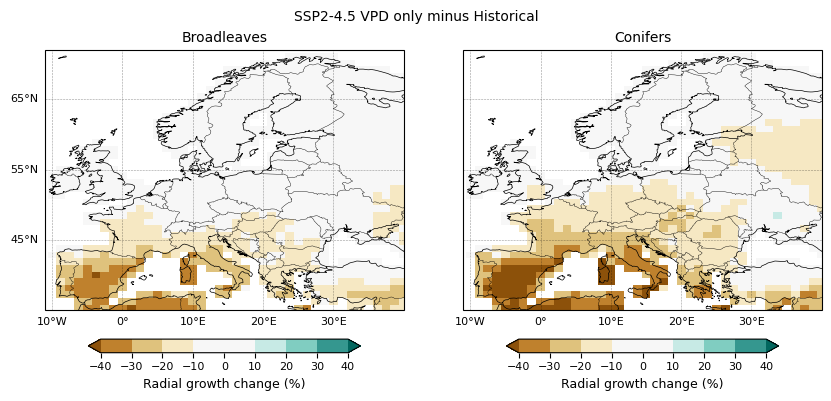

In [26]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

dif_levels_pct = np.arange(-40, 50, 10)
dif_colors_pct = ['#8c510a','#bf812d','#dfc27d','#f6e8c3','#f7f7f7',
                  '#f7f7f7','#c7eae5','#80cdc1','#35978f','#01665e']

maps = [
    (
        pct_change_broadleaves_2050_2069,
        "Broadleaves",
        dif_levels_pct,
        dif_colors_pct,
    ),
    (
        pct_change_conifers_2050_2069,
        "Conifers",
        dif_levels_pct,
        dif_colors_pct,
    ),
]

fig = plt.figure(figsize=(9, 4))
fig.suptitle(
    "SSP2-4.5 VPD only minus Historical",
    fontsize=10,
    y=0.99
)
gs = fig.add_gridspec(nrows=1, ncols=6)

axes = [
    fig.add_subplot(gs[0, 0:3], projection=ccrs.PlateCarree()),  # left
    fig.add_subplot(gs[0, 3:6], projection=ccrs.PlateCarree())   # right
]

for i, (da, title, clevels, ccolors) in enumerate(maps):
    ax = axes[i]

    # Fix longitude range and subset to Europe
    if da.lon.max() > 180:
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180)).sortby('lon')
    da = da.sel(lat=slice(35, 72), lon=slice(-11, 40))
    da = da.where(np.isfinite(da))

    # Map plot
    pcm = da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=clevels,
        colors=ccolors,
        add_colorbar=False,
        extend='both'
    )

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.set_xlim(-11, 40)
    ax.set_ylim(35, 72)
    ax.set_title(title, fontsize=10)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        linewidth=0.4, color="black", alpha=0.4, linestyle="--",
        draw_labels=True
    )
    gl.ylocator = mticker.FixedLocator([35, 45, 55, 65, 75])
    gl.xlocator = mticker.FixedLocator([-10, 0, 10, 20, 30, 40])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    if i != 0:
        gl.left_labels = False

    # Colorbar with label
    cbar = plt.colorbar(
        pcm,
        ax=ax,
        orientation="horizontal",
        fraction=0.045,
        pad=0.095,
        extend='both'
    )
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label("Radial growth change (%)", fontsize=9)

plt.tight_layout()
plt.subplots_adjust(wspace=0.01, hspace=0.20)
savedir = '/glade/derecho/scratch/brendanc/Fates_update/CESMSSP245/avg_climate'
plt.savefig(f"{savedir}/VPDonlyMaps.png", dpi=600, bbox_inches="tight")
plt.show()